In [5]:
# In[1] — thread caps (fork-safety / reproducibility)
import os
for v in ('OMP_NUM_THREADS','OPENBLAS_NUM_THREADS','MKL_NUM_THREADS',
          'VECLIB_MAXIMUM_THREADS','NUMEXPR_NUM_THREADS'):
    os.environ[v] = '1'

In [6]:
# In[2] — imports, path, reload, confirm the passthrough is in your repo
import sys, os, importlib, warnings, inspect
warnings.simplefilter(action='ignore', category=FutureWarning)
sys.path.insert(0, os.path.abspath('../../model'))
sys.path.insert(0, os.path.abspath('.'))
sys.path.insert(0, os.path.abspath('../.'))

In [3]:
import os
for v in ('OMP','OPENBLAS','MKL','VECLIB','NUMEXPR'): os.environ[f'{v}_NUM_THREADS']='1'
import importlib, numpy as np, seasonal_scan_harness as ssh; importlib.reload(ssh)
FORC = ssh.build_forcings(['pre+recovery','post'], hplc_coincident=False)
# new routed baseline; sweep ONLY fish→N (fish_fX 0.08=N0.85 ↔ 0.43=N0.50), fish D fixed 0.07
PG = {'fish_fX':[0.08, 0.43], 'fish_fD':[0.07],
      'zq_fD':[0.90], 'zq_fX':[0.0],  'zl_fD':[0.90], 'zl_fX':[0.0],
      'GGE':[0.31], 'KsZ':[0.23], 'sigma_log':[0.20], 'mP':[0.0015], 'm_Z':[0.10],
      'k_remin':[0.04], 'w_sink':[10.0]}
res_pre = ssh.run_seasonal_scan(constructs=['maranon_ward'], groups=['pre+recovery'], fish_rates=[0.5],
    param_grid=PG, years=60, spinup=15, n_harmonics=3, forcings=FORC, routed=True,
    save_path='seasonal_prelimFishN_pre_2026-06-29.pkl', processes=None, maxtasksperchild=1)
print('pre done:', len(res_pre.records))

[seasonal scan] 2 runs: ['maranon_ward'] x ['pre+recovery'] x fish=[0.5] x params['fish_fX', 'fish_fD', 'zq_fD', 'zq_fX', 'zl_fD', 'zl_fX', 'GGE', 'KsZ', 'sigma_log', 'mP', 'm_Z', 'k_remin', 'w_sink'] | 60 yr each (spin-up 15)
solver: {'method': 'RK45', 'atol': 1e-09, 'rtol': 1e-06, 'max_step': 1.0, 'instability_neg_threshold': -0.001} | fourier n_harm=3 | processes=cpu-1
  MODEL   : model_baseline_seasonal_routed   (ROUTED closure+fish)
  growth  : maranon_ward  mu_max[0.13-0.83]  Ks[0.04-10.45]
  grazing : KsZ 0.23  sigma_log 0.2  Q10 2.48
  scalars : GGE 0.31  growth-Q10 1.62  T_ref 20.0
  rates   : mP 0.0015  m_Z(quad) 0.1  m_Zlin 0.05  r_F 0.5
  detritus: k_remin 0.04  w_sink 10.0  ->  L = 250 m
  loss-fate routing (N / D / export):
     phyto mort : N 0.10 / D 0.90 / export 0.00
     graze unas : N 0.25 / D 0.75 / export 0.00
     zoo linear : N 0.10 / D 0.90 / export 0.00
     zoo quad   : N 0.10 / D 0.90 / export 0.00
     fish       : N 0.85 / D 0.07 / export 0.08
  forcing : 

In [5]:
import os
for v in ('OMP','OPENBLAS','MKL','VECLIB','NUMEXPR'): os.environ[f'{v}_NUM_THREADS']='1'
import importlib, numpy as np, seasonal_scan_harness as ssh; importlib.reload(ssh)
FORC = ssh.build_forcings(['pre+recovery','post'], hplc_coincident=False)
# new routed baseline; sweep ONLY fish→N (fish_fX 0.08=N0.85 ↔ 0.43=N0.50), fish D fixed 0.07
PG = {'fish_fX':[0.08, 0.43], 'fish_fD':[0.07],
      'zq_fD':[0.90], 'zq_fX':[0.0],  'zl_fD':[0.90], 'zl_fX':[0.0],
      'GGE':[0.31], 'KsZ':[0.23], 'sigma_log':[0.20], 'mP':[0.0015], 'm_Z':[0.10],
      'k_remin':[0.04], 'w_sink':[10.0]}
res_post = ssh.run_seasonal_scan(constructs=['maranon_ward'], groups=['post'], fish_rates=[0.1],
    param_grid=PG, years=60, spinup=15, n_harmonics=3, forcings=FORC, routed=True,
    save_path='seasonal_prelimFishN_post_2026-06-29.pkl', processes=None, maxtasksperchild=1)
print('post done:', len(res_post.records))

[seasonal scan] 2 runs: ['maranon_ward'] x ['post'] x fish=[0.1] x params['fish_fX', 'fish_fD', 'zq_fD', 'zq_fX', 'zl_fD', 'zl_fX', 'GGE', 'KsZ', 'sigma_log', 'mP', 'm_Z', 'k_remin', 'w_sink'] | 60 yr each (spin-up 15)
solver: {'method': 'RK45', 'atol': 1e-09, 'rtol': 1e-06, 'max_step': 1.0, 'instability_neg_threshold': -0.001} | fourier n_harm=3 | processes=cpu-1
  MODEL   : model_baseline_seasonal_routed   (ROUTED closure+fish)
  growth  : maranon_ward  mu_max[0.13-0.83]  Ks[0.04-10.45]
  grazing : KsZ 0.23  sigma_log 0.2  Q10 2.48
  scalars : GGE 0.31  growth-Q10 1.62  T_ref 20.0
  rates   : mP 0.0015  m_Z(quad) 0.1  m_Zlin 0.05  r_F 0.1
  detritus: k_remin 0.04  w_sink 10.0  ->  L = 250 m
  loss-fate routing (N / D / export):
     phyto mort : N 0.10 / D 0.90 / export 0.00
     graze unas : N 0.25 / D 0.75 / export 0.00
     zoo linear : N 0.10 / D 0.90 / export 0.00
     zoo quad   : N 0.10 / D 0.90 / export 0.00
     fish       : N 0.85 / D 0.07 / export 0.08
  forcing : n_harmon

In [6]:
import numpy as np, pandas as pd, seasonal_scan_harness as ssh
RP=ssh.load_results('seasonal_prelimFishN_pre_2026-06-29.pkl'); RQ=ssh.load_results('seasonal_prelimFishN_post_2026-06-29.pkl')
OBS={'pre+recovery':RP.obs['pre+recovery'],'post':RQ.obs['post']}; MO=['J','F','M','A','M','J','J','A','S','O','N','D']
od=OBS['post']['med']['Z200']-OBS['pre+recovery']['med']['Z200']
key=lambda r:round(r['fish_fX'],4)
P={key(r):r for r in RP.records}; Q={key(r):r for r in RQ.records}; rows=[]
for k in sorted(P):
    p,q=P[k],Q[k]; cz=np.asarray(q.get('clim_sumP',[np.nan]*12),float)
    rows.append(dict(fish_fX=k, fishN=round(1-0.07-k,2), fit_pre=p['score'], fit_post=q['score'],
        joint=max(p['score'],q['score']), Zmed_inv=q.get('Z200_med',np.nan)-p.get('Z200_med',np.nan),
        pze_post=q.get('pze',np.nan), pre_cv=p.get('cv_sumP',np.nan), post_cv=q.get('cv_sumP',np.nan),
        post_bl=MO[int(np.nanargmax(cz))] if np.isfinite(cz).any() else '·'))
print(f"prelim @ new routing | obs med Z inv {od:+.4f} | Mouw pze ~0.50 | fishN = 1 - 0.07 - fish_fX")
print(pd.DataFrame(rows).round(4).to_string(index=False))

prelim @ new routing | obs med Z inv +0.0035 | Mouw pze ~0.50 | fishN = 1 - 0.07 - fish_fX
 fish_fX  fishN  fit_pre  fit_post  joint  Zmed_inv  pze_post  pre_cv  post_cv post_bl
    0.08   0.85   0.2684    0.3544 0.3544   -0.0023    0.6480  1.1596   0.3997       M
    0.43   0.50   0.3000    0.3527 0.3527    0.0002    0.6576  1.1984   0.3696       M


In [7]:
import os
for v in ('OMP','OPENBLAS','MKL','VECLIB','NUMEXPR'): os.environ[f'{v}_NUM_THREADS']='1'
import importlib, numpy as np, seasonal_scan_harness as ssh; importlib.reload(ssh)
FORC = ssh.build_forcings(['pre+recovery','post'], hplc_coincident=False)
# w_sink sweep at new routing; L = w_sink/0.04 -> 125 / 187 / 250 m
PG = {'w_sink':[5.0, 7.5, 10.0], 'fish_fX':[0.08, 0.43], 'fish_fD':[0.07],
      'zq_fD':[0.90], 'zq_fX':[0.0],  'zl_fD':[0.90], 'zl_fX':[0.0],
      'GGE':[0.31], 'KsZ':[0.23], 'sigma_log':[0.20], 'mP':[0.0015], 'm_Z':[0.10],
      'k_remin':[0.04]}
res_pre = ssh.run_seasonal_scan(constructs=['maranon_ward'], groups=['pre+recovery'], fish_rates=[0.5],
    param_grid=PG, years=60, spinup=15, n_harmonics=3, forcings=FORC, routed=True,
    save_path='seasonal_wsink_pre_2026-06-29.pkl', processes=None, maxtasksperchild=1)
print('pre done:', len(res_pre.records))

[seasonal scan] 6 runs: ['maranon_ward'] x ['pre+recovery'] x fish=[0.5] x params['w_sink', 'fish_fX', 'fish_fD', 'zq_fD', 'zq_fX', 'zl_fD', 'zl_fX', 'GGE', 'KsZ', 'sigma_log', 'mP', 'm_Z', 'k_remin'] | 60 yr each (spin-up 15)
solver: {'method': 'RK45', 'atol': 1e-09, 'rtol': 1e-06, 'max_step': 1.0, 'instability_neg_threshold': -0.001} | fourier n_harm=3 | processes=cpu-1
  MODEL   : model_baseline_seasonal_routed   (ROUTED closure+fish)
  growth  : maranon_ward  mu_max[0.13-0.83]  Ks[0.04-10.45]
  grazing : KsZ 0.23  sigma_log 0.2  Q10 2.48
  scalars : GGE 0.31  growth-Q10 1.62  T_ref 20.0
  rates   : mP 0.0015  m_Z(quad) 0.1  m_Zlin 0.05  r_F 0.5
  detritus: k_remin 0.04  w_sink 5.0  ->  L = 125 m
  loss-fate routing (N / D / export):
     phyto mort : N 0.10 / D 0.90 / export 0.00
     graze unas : N 0.25 / D 0.75 / export 0.00
     zoo linear : N 0.10 / D 0.90 / export 0.00
     zoo quad   : N 0.10 / D 0.90 / export 0.00
     fish       : N 0.85 / D 0.07 / export 0.08
  forcing : n

In [8]:
import os
for v in ('OMP','OPENBLAS','MKL','VECLIB','NUMEXPR'): os.environ[f'{v}_NUM_THREADS']='1'
import importlib, numpy as np, seasonal_scan_harness as ssh; importlib.reload(ssh)
FORC = ssh.build_forcings(['pre+recovery','post'], hplc_coincident=False)
# w_sink sweep at new routing; L = w_sink/0.04 -> 125 / 187 / 250 m
PG = {'w_sink':[5.0, 7.5, 10.0], 'fish_fX':[0.08, 0.43], 'fish_fD':[0.07],
      'zq_fD':[0.90], 'zq_fX':[0.0],  'zl_fD':[0.90], 'zl_fX':[0.0],
      'GGE':[0.31], 'KsZ':[0.23], 'sigma_log':[0.20], 'mP':[0.0015], 'm_Z':[0.10],
      'k_remin':[0.04]}
res_pre = ssh.run_seasonal_scan(constructs=['maranon_ward'], groups=['post'], fish_rates=[0.1],
    param_grid=PG, years=60, spinup=15, n_harmonics=3, forcings=FORC, routed=True,
    save_path='seasonal_wsink_post_2026-06-29.pkl', processes=None, maxtasksperchild=1)
print('pre done:', len(res_pre.records))

[seasonal scan] 6 runs: ['maranon_ward'] x ['post'] x fish=[0.1] x params['w_sink', 'fish_fX', 'fish_fD', 'zq_fD', 'zq_fX', 'zl_fD', 'zl_fX', 'GGE', 'KsZ', 'sigma_log', 'mP', 'm_Z', 'k_remin'] | 60 yr each (spin-up 15)
solver: {'method': 'RK45', 'atol': 1e-09, 'rtol': 1e-06, 'max_step': 1.0, 'instability_neg_threshold': -0.001} | fourier n_harm=3 | processes=cpu-1
  MODEL   : model_baseline_seasonal_routed   (ROUTED closure+fish)
  growth  : maranon_ward  mu_max[0.13-0.83]  Ks[0.04-10.45]
  grazing : KsZ 0.23  sigma_log 0.2  Q10 2.48
  scalars : GGE 0.31  growth-Q10 1.62  T_ref 20.0
  rates   : mP 0.0015  m_Z(quad) 0.1  m_Zlin 0.05  r_F 0.1
  detritus: k_remin 0.04  w_sink 5.0  ->  L = 125 m
  loss-fate routing (N / D / export):
     phyto mort : N 0.10 / D 0.90 / export 0.00
     graze unas : N 0.25 / D 0.75 / export 0.00
     zoo linear : N 0.10 / D 0.90 / export 0.00
     zoo quad   : N 0.10 / D 0.90 / export 0.00
     fish       : N 0.85 / D 0.07 / export 0.08
  forcing : n_harmoni

In [9]:
import numpy as np, pandas as pd, seasonal_scan_harness as ssh
RP=ssh.load_results('seasonal_wsink_pre_2026-06-29.pkl'); RQ=ssh.load_results('seasonal_wsink_post_2026-06-29.pkl')
OBS={'pre+recovery':RP.obs['pre+recovery'],'post':RQ.obs['post']}; MO=['J','F','M','A','M','J','J','A','S','O','N','D']
od=OBS['post']['med']['Z200']-OBS['pre+recovery']['med']['Z200']
key=lambda r:(round(r['w_sink'],3), round(r['fish_fX'],3))
P={key(r):r for r in RP.records}; Q={key(r):r for r in RQ.records}; rows=[]
for k in sorted(P):
    p,q=P[k],Q[k]; ws,fx=k; cz=np.asarray(q.get('clim_sumP',[np.nan]*12),float)
    rows.append(dict(w_sink=ws, fishN=round(1-0.07-fx,2), fit_pre=p['score'], fit_post=q['score'],
        joint=max(p['score'],q['score']), Zmed_inv=q.get('Z200_med',np.nan)-p.get('Z200_med',np.nan),
        pze_post=q.get('pze',np.nan), pre_cv=p.get('cv_sumP',np.nan), post_cv=q.get('cv_sumP',np.nan),
        post_bl=MO[int(np.nanargmax(cz))] if np.isfinite(cz).any() else '·'))
print(f"w_sink scan @ new routing (k_remin 0.04) | obs med Z inv {od:+.4f} | Mouw pze ~0.50")
print(pd.DataFrame(rows).round(4).to_string(index=False))

w_sink scan @ new routing (k_remin 0.04) | obs med Z inv +0.0035 | Mouw pze ~0.50
 w_sink  fishN  fit_pre  fit_post  joint  Zmed_inv  pze_post  pre_cv  post_cv post_bl
    5.0   0.85   0.2283    0.2665 0.2665   -0.0029    0.5611  1.1346   0.3894       M
    5.0   0.50   0.2135    0.2720 0.2720    0.0020    0.5708  1.0272   0.3909       M
    7.5   0.85   0.2454    0.2864 0.2864   -0.0010    0.6165  1.1054   0.4113       M
    7.5   0.50   0.2867    0.2707 0.2867   -0.0018    0.6263  1.2082   0.3973       M
   10.0   0.85   0.2855    0.3544 0.3544   -0.0022    0.6480  1.1772   0.3997       M
   10.0   0.50   0.2988    0.3527 0.3527    0.0001    0.6576  1.2007   0.3696       M


In [14]:
np.linspace(0.0, 0.7, 15)

array([0.  , 0.05, 0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 ,
       0.55, 0.6 , 0.65, 0.7 ])

In [15]:
import os
for v in ('OMP','OPENBLAS','MKL','VECLIB','NUMEXPR'): os.environ[f'{v}_NUM_THREADS']='1'
import importlib, numpy as np, seasonal_scan_harness as ssh; importlib.reload(ssh)
FORC = ssh.build_forcings(['pre+recovery','post'], hplc_coincident=False)
RF = list(np.linspace(0.0, 0.7, 15))        # 0, 0.05, ..., 0.70  -> parallelised r_F axis
PG = {'w_sink':[5.0], 'fish_fX':[0.43], 'fish_fD':[0.07],
      'zq_fD':[0.90], 'zq_fX':[0.0], 'zl_fD':[0.90], 'zl_fX':[0.0],
      'GGE':[0.31], 'KsZ':[0.23], 'sigma_log':[0.20], 'mP':[0.0015], 'm_Z':[0.10],
      'k_remin':[0.04]}
res_pre = ssh.run_seasonal_scan(constructs=['maranon_ward'], groups=['pre+recovery'], fish_rates=RF,
    param_grid=PG, years=60, spinup=15, n_harmonics=3, forcings=FORC, routed=True,
    save_path='seasonal_rF_pre_2026-06-29.pkl', processes=None, maxtasksperchild=1)
print('pre done:', len(res_pre.records))

[seasonal scan] 15 runs: ['maranon_ward'] x ['pre+recovery'] x fish=[np.float64(0.0), np.float64(0.049999999999999996), np.float64(0.09999999999999999), np.float64(0.15), np.float64(0.19999999999999998), np.float64(0.24999999999999997), np.float64(0.3), np.float64(0.35), np.float64(0.39999999999999997), np.float64(0.44999999999999996), np.float64(0.49999999999999994), np.float64(0.5499999999999999), np.float64(0.6), np.float64(0.6499999999999999), np.float64(0.7)] x params['w_sink', 'fish_fX', 'fish_fD', 'zq_fD', 'zq_fX', 'zl_fD', 'zl_fX', 'GGE', 'KsZ', 'sigma_log', 'mP', 'm_Z', 'k_remin'] | 60 yr each (spin-up 15)
solver: {'method': 'RK45', 'atol': 1e-09, 'rtol': 1e-06, 'max_step': 1.0, 'instability_neg_threshold': -0.001} | fourier n_harm=3 | processes=cpu-1
  MODEL   : model_baseline_seasonal_routed   (ROUTED closure+fish)
  growth  : maranon_ward  mu_max[0.13-0.83]  Ks[0.04-10.45]
  grazing : KsZ 0.23  sigma_log 0.2  Q10 2.48
  scalars : GGE 0.31  growth-Q10 1.62  T_ref 20.0
  rate

In [16]:
import os
for v in ('OMP','OPENBLAS','MKL','VECLIB','NUMEXPR'): os.environ[f'{v}_NUM_THREADS']='1'
import importlib, numpy as np, seasonal_scan_harness as ssh; importlib.reload(ssh)
FORC = ssh.build_forcings(['pre+recovery','post'], hplc_coincident=False)
RF = list(np.linspace(0.0, 0.7, 15))        # 0, 0.05, ..., 0.70  -> parallelised r_F axis
PG = {'w_sink':[5.0], 'fish_fX':[0.43], 'fish_fD':[0.07],
      'zq_fD':[0.90], 'zq_fX':[0.0], 'zl_fD':[0.90], 'zl_fX':[0.0],
      'GGE':[0.31], 'KsZ':[0.23], 'sigma_log':[0.20], 'mP':[0.0015], 'm_Z':[0.10],
      'k_remin':[0.04]}
res_pre = ssh.run_seasonal_scan(constructs=['maranon_ward'], groups=['post'], fish_rates=RF,
    param_grid=PG, years=60, spinup=15, n_harmonics=3, forcings=FORC, routed=True,
    save_path='seasonal_rF_post_2026-06-29.pkl', processes=None, maxtasksperchild=1)
print('pre done:', len(res_pre.records))

[seasonal scan] 15 runs: ['maranon_ward'] x ['post'] x fish=[np.float64(0.0), np.float64(0.049999999999999996), np.float64(0.09999999999999999), np.float64(0.15), np.float64(0.19999999999999998), np.float64(0.24999999999999997), np.float64(0.3), np.float64(0.35), np.float64(0.39999999999999997), np.float64(0.44999999999999996), np.float64(0.49999999999999994), np.float64(0.5499999999999999), np.float64(0.6), np.float64(0.6499999999999999), np.float64(0.7)] x params['w_sink', 'fish_fX', 'fish_fD', 'zq_fD', 'zq_fX', 'zl_fD', 'zl_fX', 'GGE', 'KsZ', 'sigma_log', 'mP', 'm_Z', 'k_remin'] | 60 yr each (spin-up 15)
solver: {'method': 'RK45', 'atol': 1e-09, 'rtol': 1e-06, 'max_step': 1.0, 'instability_neg_threshold': -0.001} | fourier n_harm=3 | processes=cpu-1
  MODEL   : model_baseline_seasonal_routed   (ROUTED closure+fish)
  growth  : maranon_ward  mu_max[0.13-0.83]  Ks[0.04-10.45]
  grazing : KsZ 0.23  sigma_log 0.2  Q10 2.48
  scalars : GGE 0.31  growth-Q10 1.62  T_ref 20.0
  rates   : mP

In [17]:
import numpy as np, pandas as pd, seasonal_scan_harness as ssh
RP=ssh.load_results('seasonal_rF_pre_2026-06-29.pkl'); RQ=ssh.load_results('seasonal_rF_post_2026-06-29.pkl')
OBS={'pre+recovery':RP.obs['pre+recovery'],'post':RQ.obs['post']}; MO=['J','F','M','A','M','J','J','A','S','O','N','D']
od=OBS['post']['med']['Z200']-OBS['pre+recovery']['med']['Z200']
def etab(R):
    out=[]
    for r in sorted(R.records,key=lambda x:x['fish']):
        cz=np.asarray(r.get('clim_sumP',[np.nan]*12),float)
        out.append(dict(r_F=round(r['fish'],3), score=r['score'], Zmed=r.get('Z200_med',np.nan),
            pze=r.get('pze',np.nan), cv=r.get('cv_sumP',np.nan),
            bl=MO[int(np.nanargmax(cz))] if np.isfinite(cz).any() else '·'))
    return pd.DataFrame(out)
print(f"obs med Z inv {od:+.4f} | Mouw pze ~0.50 | held: w_sink5 / N0.50 / GGE0.31 / sig0.20\n")
print("PRE+REC vs r_F:\n", etab(RP).round(4).to_string(index=False))
print("\nPOST vs r_F:\n",   etab(RQ).round(4).to_string(index=False))
P=sorted(RP.records,key=lambda x:x['fish']); Q=sorted(RQ.records,key=lambda x:x['fish']); pr=[]
for p in P:
    for q in Q:
        pr.append(dict(rF_pre=round(p['fish'],3), rF_post=round(q['fish'],3), joint=max(p['score'],q['score']),
            Zmed_inv=q.get('Z200_med',np.nan)-p.get('Z200_med',np.nan), pze_post=q.get('pze',np.nan),
            fit_pre=p['score'], fit_post=q['score']))
D=pd.DataFrame(pr)
cand=D[(D.Zmed_inv>=0.0025) & (D.rF_post<=D.rF_pre)].sort_values('joint')   # near-obs cascade, post fish ≤ pre, best fit
print(f"\nbest pre×post pairs (Zmed_inv≥+0.0025, rF_post≤rF_pre), best joint first ({len(cand)}/{len(D)}):")
print(cand.head(15).round(4).to_string(index=False))

obs med Z inv +0.0035 | Mouw pze ~0.50 | held: w_sink5 / N0.50 / GGE0.31 / sig0.20

PRE+REC vs r_F:
  r_F  score   Zmed    pze     cv bl
0.00 0.5490 0.0472 0.5945 0.6097  A
0.05 0.4318 0.0423 0.5913 0.6173  M
0.10 0.4742 0.0327 0.5891 0.6516  M
0.15 0.4746 0.0324 0.5884 0.5774  M
0.20 0.4210 0.0274 0.5866 0.9196  A
0.25 0.3693 0.0282 0.5838 0.8418  M
0.30 0.3657 0.0132 0.5849 1.0281  A
0.35 0.3453 0.0109 0.5827 0.9652  A
0.40 0.2804 0.0141 0.5830 0.9376  M
0.45 0.2487 0.0129 0.5814 1.0297  M
0.50 0.2137 0.0103 0.5797 1.0284  A
0.55 0.2889 0.0122 0.5796 1.2777  M
0.60 0.2667 0.0135 0.5779 1.2634  M
0.65 0.2148 0.0086 0.5767 1.1870  M
0.70 0.2051 0.0051 0.5769 1.2072  M

POST vs r_F:
  r_F  score   Zmed    pze     cv bl
0.00 0.5495 0.0171 0.5739 0.3422  M
0.05 0.3421 0.0122 0.5723 0.3641  M
0.10 0.2720 0.0124 0.5708 0.3909  M
0.15 0.3950 0.0119 0.5693 0.3676  M
0.20 0.2812 0.0065 0.5688 0.4715  A
0.25 0.4156 0.0035 0.5672 0.4289  A
0.30 0.3430 0.0028 0.5674 0.5626  M
0.35 0.3910 0.0023 0

In [18]:
# === Fig 4 r_F sweep readout: per-era + cross pre×post (paste & run; nothing re-runs) ===
import numpy as np, pandas as pd
from seasonal_scan_harness import load_results, SCORE_KEYS, score

# ---- decision knobs (defaults = handover rule; flip freely) -------------------
OBS_INV_TARGET   = 0.0035     # obs median Z>200 inversion to reach
INV_TOL          = 0.0010     # |model_inv - target| to count as "reaches"
PZE_LO, PZE_HI   = 0.40, 0.60 # soft pze window (annotation only, not a gate)
JOINT            = 'max'      # combine pre/post fit: 'max' (fit BOTH) | 'mean'
USE_SUMP_IN_FIT  = True       # 5-key composition+ΣP (stored .score is 4-key!)
TOPN             = 12

RP = load_results('seasonal_rF_pre_2026-06-29.pkl')    # group = pre+recovery
RQ = load_results('seasonal_rF_post_2026-06-29.pkl')   # group = post
# per-era pickle obs holds ONLY that era -> assemble both (handover footgun)
OBS = {'pre+recovery': RP.obs['pre+recovery'], 'post': RQ.obs['post']}

KEYS = list(SCORE_KEYS) + (['sumP'] if USE_SUMP_IN_FIT else [])
W = {k: 1.0 for k in KEYS}
def era_fit(rec, g):                       # max(mean-dist, median-dist) over KEYS
    d_med  = score({k: rec.get(k+'_med', np.nan) for k in KEYS}, OBS[g]['med'],  W)
    d_mean = score({k: rec.get(k,        np.nan) for k in KEYS}, OBS[g]['mean'], W)
    return float(np.nanmax([d_med, d_mean]))

pre  = RP.df.copy();  pre['fit']  = [era_fit(r, 'pre+recovery') for r in RP.records]
post = RQ.df.copy();  post['fit'] = [era_fit(r, 'post')         for r in RQ.records]
obs_inv = OBS['post']['med']['Z200'] - OBS['pre+recovery']['med']['Z200']

# ---- per-era r_F response ----------------------------------------------------
def era_tbl(d, g):
    t = d[['fish','Z200_med','fit','pze','cv_sumP','has_nan']].copy()
    t.insert(2, 'obs_Z200_med', OBS[g]['med']['Z200'])
    return t.sort_values('fish').round(4)
print(f"obs median Z>200 inversion (post − pre+rec) = {obs_inv:+.4f}  (target {OBS_INV_TARGET:+.4f})")
print(f"pre cv range {pre.cv_sumP.min():.2f}–{pre.cv_sumP.max():.2f} | "
      f"post cv {post.cv_sumP.min():.2f}–{post.cv_sumP.max():.2f} | "
      f"nan pre {int(pre.has_nan.sum())} post {int(post.has_nan.sum())}")
print("\n--- PRE+RECOVERY r_F response ---");  print(era_tbl(pre,  'pre+recovery').to_string(index=False))
print("\n--- POST r_F response ---");          print(era_tbl(post, 'post').to_string(index=False))

# ---- cross pre×post (enforce rF_post <= rF_pre) ------------------------------
rows = []
for _, a in pre.iterrows():
    for _, b in post.iterrows():
        if b.fish > a.fish + 1e-9:               # post-collapse = fewer fish
            continue
        inv   = b.Z200_med - a.Z200_med
        joint = max(a.fit, b.fit) if JOINT == 'max' else 0.5*(a.fit + b.fit)
        rows.append(dict(rF_pre=a.fish, rF_post=b.fish, inv=inv,
                         d_inv=abs(inv - OBS_INV_TARGET), joint_fit=joint,
                         fit_pre=a.fit, fit_post=b.fit,
                         pze_pre=a.pze, pze_post=b.pze,
                         cv_pre=a.cv_sumP, cv_post=b.cv_sumP,
                         nan=bool(a.has_nan or b.has_nan)))
X = pd.DataFrame(rows)
X['pze_ok'] = X.pze_pre.between(PZE_LO,PZE_HI) & X.pze_post.between(PZE_LO,PZE_HI)
stable = X[~X.nan]

print(f"\nmax achievable model inversion = {stable.inv.max():+.4f} "
      f"({100*stable.inv.max()/OBS_INV_TARGET:.0f}% of target) | "
      f"pairs reaching target±{INV_TOL}: {int((stable.d_inv<=INV_TOL).sum())}/{len(stable)}")

cols = ['rF_pre','rF_post','inv','joint_fit','fit_pre','fit_post','pze_pre','pze_post','cv_pre','cv_post','pze_ok']
hits = stable[stable.d_inv <= INV_TOL].sort_values('joint_fit')
print(f"\n--- DECISION: reaches inversion, best joint fit (rF_post≤rF_pre) ---")
print((hits[cols].head(TOPN).round(4).to_string(index=False)) if len(hits)
      else "  >> none reach target window — widen INV_TOL or use GGE×σ_log fallback")
print(f"\n--- frontier: best inversion regardless of fit (under-reach check) ---")
print(stable.sort_values('inv', ascending=False)[cols].head(TOPN).round(4).to_string(index=False))
print(f"\n--- best joint fit overall (composition anchor) ---")
print(stable.sort_values('joint_fit')[cols].head(TOPN).round(4).to_string(index=False))

obs median Z>200 inversion (post − pre+rec) = +0.0035  (target +0.0035)
pre cv range 0.58–1.28 | post cv 0.34–0.74 | nan pre 0 post 0

--- PRE+RECOVERY r_F response ---
 fish  Z200_med  obs_Z200_med    fit    pze  cv_sumP  has_nan
 0.00    0.0472         0.053 0.5002 0.5945   0.6097    False
 0.05    0.0423         0.053 0.3911 0.5913   0.6173    False
 0.10    0.0327         0.053 0.4315 0.5891   0.6516    False
 0.15    0.0324         0.053 0.4318 0.5884   0.5774    False
 0.20    0.0274         0.053 0.3876 0.5866   0.9196    False
 0.25    0.0282         0.053 0.3381 0.5838   0.8418    False
 0.30    0.0132         0.053 0.3371 0.5849   1.0281    False
 0.35    0.0109         0.053 0.3181 0.5827   0.9652    False
 0.40    0.0141         0.053 0.2567 0.5830   0.9376    False
 0.45    0.0129         0.053 0.2286 0.5814   1.0297    False
 0.50    0.0103         0.053 0.1960 0.5797   1.0284    False
 0.55    0.0122         0.053 0.2661 0.5796   1.2777    False
 0.60    0.0135         0


##### pre+recovery  r_F=0.65 #####
  MODEL   : model_baseline_seasonal_routed   (ROUTED closure+fish)
  growth  : maranon_ward  mu_max[0.13-0.83]  Ks[0.04-10.45]
  grazing : KsZ 0.23  sigma_log 0.2  Q10 2.48
  scalars : GGE 0.31  growth-Q10 1.62  T_ref 20.0
  rates   : mP 0.0015  m_Z(quad) 0.1  m_Zlin 0.05  r_F 0.65
  detritus: k_remin 0.04  w_sink 5.0  ->  L = 125 m
  loss-fate routing (N / D / export):
     phyto mort : N 0.10 / D 0.90 / export 0.00
     graze unas : N 0.25 / D 0.75 / export 0.00
     zoo linear : N 0.10 / D 0.90 / export 0.00
     zoo quad   : N 0.10 / D 0.90 / export 0.00
     fish       : N 0.50 / D 0.07 / export 0.43
  forcing : n_harmonics 3  fit @ cruise DOY  | F_N[1.45-5.71]  d_e[30-54]  T[22.4-25.9]
  solver  : {'method': 'RK45', 'atol': 1e-09, 'rtol': 1e-06, 'max_step': 1.0, 'instability_neg_threshold': -0.001}

##### post  r_F=0.1 #####
  MODEL   : model_baseline_seasonal_routed   (ROUTED closure+fish)
  growth  : maranon_ward  mu_max[0.13-0.83]  Ks[0.04-1

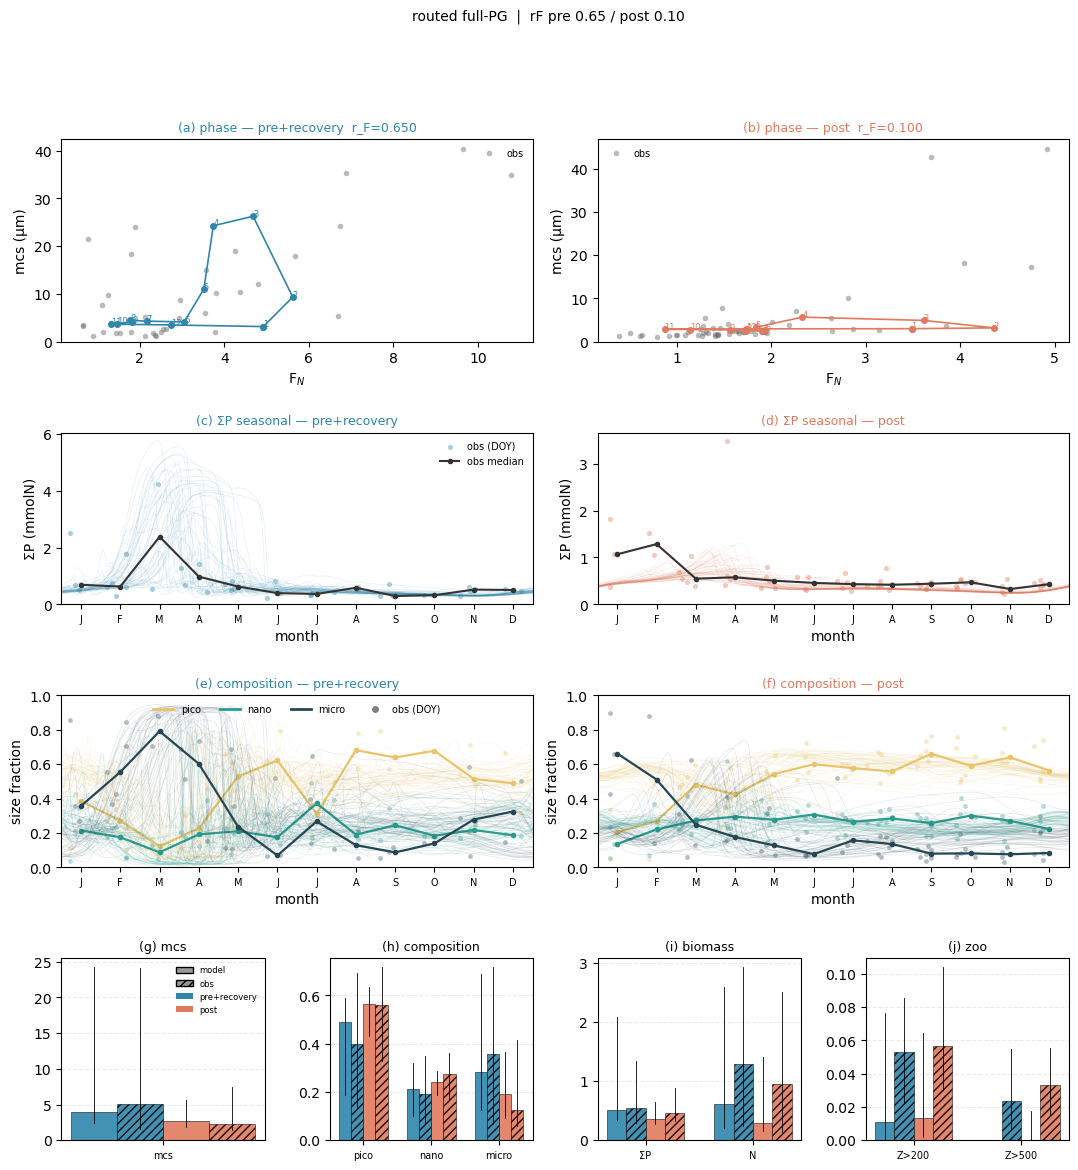

In [22]:
# === Fig 4 overview — best pair rF_pre 0.65 / rF_post 0.10 (matches the sweep PG exactly) ===
import os
for v in ('OMP','OPENBLAS','MKL','VECLIB','NUMEXPR'): os.environ[f'{v}_NUM_THREADS']='1'
import importlib, numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D; from matplotlib.patches import Patch
import seasonal_scan_harness as ssh; importlib.reload(ssh)
from baseline_r0_seasonal_comps import _MID_MONTH_DOY

ERAS = ['pre+recovery','post']
FISH = {'pre+recovery':0.65, 'post':0.10}
MP, MZ = 0.0015, 0.10                       # run_one args (NOT iv_overrides), per PG
HELD = {'DetritusSink':{'w_sink':5.0}, 'DetritusRemin':{'k_remin':0.04},
        'GrazingRouter':{'gge':0.31}, 'Grazing':{'KsZ':0.23, 'sigma_log':0.20},
        'FishGrazing':{'frac_export':0.43, 'frac_D':0.07},      # fish -> N 0.50 / D 0.07 / exp 0.43
        'ZooQuadMortality':{'frac_D':0.90, 'frac_export':0.0},  # -> N 0.10 / D 0.90
        'ZooLinMortality':{'frac_D':0.90, 'frac_export':0.0}}   # -> N 0.10 / D 0.90
YEARS, SPINUP = 60, 15
PICKLES = [f"routed full-PG  |  rF pre {FISH['pre+recovery']:.2f} / post {FISH['post']:.2f}"]
PICKLE_IDX = 0

construct = ssh.allometry('maranon_ward')
forcings  = ssh.build_forcings(ERAS, hplc_coincident=False)
obs       = ssh.build_obs_targets(ERAS)

runs, clims = {}, {}
for era in ERAS:
    print(f"\n##### {era}  r_F={FISH[era]} #####")
    ssh.describe_run(construct, forcings[era], fish_rate=FISH[era], mP=MP, m_Z=MZ,
                     iv_overrides=HELD, n_harmonics=3, routed=True)   # zoo-quad/lin should now read N 0.10/D 0.90, fish D 0.07, mP 0.0015
    clim, r = ssh.run_one(construct, forcings[era], fish_rate=FISH[era], mP=MP, m_Z=MZ,
                          years=YEARS, spinup=SPINUP, iv_overrides=HELD,
                          n_harmonics=3, routed=True, return_traj=True)
    runs[era], clims[era] = r, clim

# ---- headline diagnostics (should now match the sweep: pre fit5 ~0.198 Zmed ~0.0086, post ~0.264 Zmed ~0.0124) ----
KEYS5=['mcs','pico','nano','micro','sumP']; W5={k:1. for k in KEYS5}
def fit5(c,g):
    dm=ssh.score({k:c.get(k+'_med',np.nan) for k in KEYS5}, obs[g]['med'],  W5)
    da=ssh.score({k:c.get(k,np.nan)        for k in KEYS5}, obs[g]['mean'], W5)
    return float(np.nanmax([dm,da]))
_MOS=['J','F','M','A','M','J','J','A','S','O','N','D']; rows=[]
for era in ERAS:
    c=clims[era]
    rows.append(dict(era=era, r_F=FISH[era], fit5=round(fit5(c,era),4),
        Zmed=round(c['Z200_med'],4), obs_Zmed=round(obs[era]['med']['Z200'],4),
        pze=round(c['pze'],3), cv=round(c['cv_sumP'],3),
        bloom=_MOS[int(np.nanargmax(c['clim_sumP']))], has_nan=c['has_nan']))
inv=clims['post']['Z200_med']-clims['pre+recovery']['Z200_med']
obs_inv=obs['post']['med']['Z200']-obs['pre+recovery']['med']['Z200']
print("\n"+pd.DataFrame(rows).to_string(index=False))
print(f"\nmodel Z>200 median inversion (post-pre) = {inv:+.4f}  |  obs = {obs_inv:+.4f}")
print(f"NOTE: model Z>200 level ~{obs['post']['med']['Z200']/max(clims['post']['Z200_med'],1e-9):.1f}x below obs "
      f"(we match the DIFFERENCE, not the standing stock)")

# ===================== your figure block (unchanged below) ============================
SPINUP=15; _MO=np.arange(1,13); MO=['J','F','M','A','M','J','J','A','S','O','N','D']
ECOL={'pre+recovery':'#2E86AB','post':'#E07A5F'}; CLS=[('pico','#E9C46A'),('nano','#2A9D8F'),('micro','#264653')]
obs_m=ssh.build_obs_monthly(ERAS,forcing_complete=True)
def doy_to_mo(d): return np.interp(np.asarray(d,float),np.r_[0,_MID_MONTH_DOY,365],np.r_[0.5,_MO.astype(float),12.5])
def ox(df,col='doy_hplc'):
    d=df[col] if col in df else pd.Series(np.nan,index=df.index)
    return np.where(np.isfinite(d),doy_to_mo(d),df['mo'])
def _clim(r,k):
    keep=r['t']>=SPINUP*365.0; mo=np.clip(np.searchsorted(ssh._MEDGES,np.mod(r['t'][keep],365.0),'right')+1,1,12)
    v=np.asarray(r[k],float)[keep]; return np.array([np.nanmean(v[mo==m]) if np.any(mo==m) else np.nan for m in _MO])
def _vals(r,k):
    keep=r['t']>=SPINUP*365.0; t=r['t'][keep]; mo=np.clip(np.searchsorted(ssh._MEDGES,np.mod(t,365.0),'right')+1,1,12)
    yr=(t/365.0).astype(int); v=np.asarray(r[k],float)[keep]
    return np.array([np.nanmean(v[(yr==y)&(mo==m)]) for y in np.unique(yr) for m in _MO if np.any((yr==y)&(mo==m))])
def _daily(r,k):
    keep=r['t']>=SPINUP*365.0; t=r['t'][keep]; v=np.asarray(r[k],float)[keep]; doy=np.mod(t,365.0); yr=(t/365.0).astype(int); out=[]
    for y in np.unique(yr): m=yr==y; o=np.argsort(doy[m]); out.append((doy[m][o],v[m][o]))
    return out
def _d2m(d): return np.interp(d,np.r_[0,_MID_MONTH_DOY,365],np.r_[0.5,_MO.astype(float),12.5])
def _bar(ax,x,vals,c,h=None,w=0.18):
    v=np.asarray(vals,float); v=v[np.isfinite(v)]
    if v.size==0: return
    lo,hi=np.percentile(v,[10,90]); ax.bar(x,np.median(v),w,color=c,alpha=.9,hatch=h,edgecolor='k',lw=.4,zorder=2); ax.plot([x,x],[lo,hi],color='k',lw=.6,zorder=4)
fig=plt.figure(figsize=(13,13)); gs=GridSpec(4,4,figure=fig,height_ratios=[1,.85,.85,.9],hspace=.5,wspace=.32)
for col,era in zip([slice(0,2),slice(2,4)],ERAS):
    ax=fig.add_subplot(gs[0,col]); c=ECOL[era]; r=runs[era]; fn,mc=_clim(r,'FN'),_clim(r,'mcs'); o=np.r_[np.arange(12),0]
    ax.plot(fn[o],mc[o],'-o',color=c,lw=1.2,ms=4)
    for m in _MO: ax.annotate(str(m),(fn[m-1],mc[m-1]),fontsize=6,color=c)
    om=obs_m[era].dropna(subset=['FN','mcs']); ax.scatter(om['FN'],om['mcs'],s=16,color='0.4',alpha=.45,lw=0,label='obs')
    ax.set_xlabel('F$_N$'); ax.set_ylabel('mcs (µm)'); ax.set_ylim(bottom=0)
    ax.set_title(f"({'ab'[ERAS.index(era)]}) phase — {era}  r_F={FISH[era]:.3f}",fontsize=9,color=c); ax.legend(fontsize=7,frameon=False)
for col,era in zip([slice(0,2),slice(2,4)],ERAS):
    ax=fig.add_subplot(gs[1,col]); r=runs[era]; c=ECOL[era]; om=obs_m[era].dropna(subset=['sumP'])
    for doy,v in _daily(r,'sumP'): ax.plot(_d2m(doy),v,'-',color=c,alpha=.12,lw=.5)
    ax.scatter(ox(om),om['sumP'],s=14,color=c,alpha=.4,lw=0,label='obs (DOY)')
    ax.plot(_MO,om.groupby('mo')['sumP'].median().reindex(_MO).values,'-o',color='0.2',lw=1.5,ms=3,label='obs median')
    allv=np.concatenate([v for _,v in _daily(r,'sumP')]+[om['sumP'].to_numpy()])
    ax.set_xlim(.5,12.5); ax.set_xticks(_MO); ax.set_xticklabels(MO,fontsize=7); ax.set_ylim(0,np.max(allv)*1.05)
    ax.set_xlabel('month'); ax.set_ylabel('ΣP (mmolN)'); ax.set_title(f"({'cd'[ERAS.index(era)]}) ΣP seasonal — {era}",fontsize=9,color=c)
    if col.start==0: ax.legend(fontsize=7,frameon=False)
for col,era in zip([slice(0,2),slice(2,4)],ERAS):
    ax=fig.add_subplot(gs[2,col]); r=runs[era]; om=obs_m[era]
    for cls,cc in CLS:
        for doy,v in _daily(r,cls): ax.plot(_d2m(doy),v,'-',color=cc,alpha=.12,lw=.5)
        o=om.dropna(subset=[cls]); ax.scatter(ox(o),o[cls],s=12,color=cc,alpha=.35,lw=0)
        ax.plot(_MO,o.groupby('mo')[cls].median().reindex(_MO).values,'-o',color=cc,lw=1.6,ms=3)
    ax.set_xlim(.5,12.5); ax.set_xticks(_MO); ax.set_xticklabels(MO,fontsize=7); ax.set_ylim(0,1)
    ax.set_xlabel('month'); ax.set_ylabel('size fraction'); ax.set_title(f"({'ef'[ERAS.index(era)]}) composition — {era}",fontsize=9,color=ECOL[era])
    if col.start==0: ax.legend([Line2D([],[],color=cc,lw=2) for _,cc in CLS]+[Line2D([],[],color='.5',marker='o',ls='',ms=4)],[c for c,_ in CLS]+['obs (DOY)'],fontsize=7,frameon=False,ncol=4,loc='upper center')
BP=[('(g) mcs',[('mcs','mcs')]),('(h) composition',[('pico','pico'),('nano','nano'),('micro','micro')]),('(i) biomass',[('ΣP','sumP'),('N','N')]),('(j) zoo',[('Z>200','Z200'),('Z>500','Z500')])]
W=0.18; OFF={('pre+recovery','m'):-1.5*W,('pre+recovery','o'):-.5*W,('post','m'):.5*W,('post','o'):1.5*W}
for j,(title,metrics) in enumerate(BP):
    ax=fig.add_subplot(gs[3,j])
    for i,(lab,key) in enumerate(metrics):
        for era in ERAS:
            c=ECOL[era]; _bar(ax,i+OFF[(era,'m')],_vals(runs[era],key),c,None,W)
            obs=obs_m[era][key].dropna().to_numpy() if key in obs_m[era].columns else np.array([])
            _bar(ax,i+OFF[(era,'o')],obs,c,'////',W)
    ax.set_xticks(range(len(metrics))); ax.set_xticklabels([m[0] for m in metrics],fontsize=7); ax.set_title(title,fontsize=9); ax.set_ylim(bottom=0); ax.grid(axis='y',ls='--',alpha=.25)
    if j==0: ax.legend([Patch(fc='.6',ec='k'),Patch(fc='.6',ec='k',hatch='////')]+[Patch(fc=ECOL[e]) for e in ERAS],['model','obs']+list(ERAS),fontsize=6,frameon=False)
fig.suptitle(f"{PICKLES[PICKLE_IDX]}",fontsize=10); plt.show()

In [26]:
import os
for v in ('OMP','OPENBLAS','MKL','VECLIB','NUMEXPR'): os.environ[f'{v}_NUM_THREADS']='1'
import importlib, numpy as np, seasonal_scan_harness as ssh; importlib.reload(ssh)
FORC = ssh.build_forcings(['pre+recovery','post'], hplc_coincident=False)
RF_PRE = [0.3, 0.4, 0.5, 0.55, 0.6, 0.65]                 # added 0.55, 0.6 — the target band
PG = {'w_sink':[5.0], 'fish_fX':[0.43], 'fish_fD':[0.07],
      'zq_fD':[0.90], 'zq_fX':[0.0], 'zl_fD':[0.90], 'zl_fX':[0.0],
      'GGE':[0.31], 'KsZ':[0.15, 0.23, 0.45], 'sigma_log':[0.20], 'mP':[0.0015], 'm_Z':[0.10],
      'k_remin':[0.04]}                                   # only KsZ varies; rest = pinned candidate
res = ssh.run_seasonal_scan(constructs=['maranon_ward'], groups=['pre+recovery'], fish_rates=RF_PRE,
    param_grid=PG, years=60, spinup=15, n_harmonics=3, forcings=FORC, routed=True,
    save_path='seasonal_KsZ_pre_2026-06-29.pkl', processes=None, maxtasksperchild=1)
print('KsZ pre done:', len(res.records), '(expect 18 = 3 KsZ x 6 r_F)')

[seasonal scan] 18 runs: ['maranon_ward'] x ['pre+recovery'] x fish=[0.3, 0.4, 0.5, 0.55, 0.6, 0.65] x params['w_sink', 'fish_fX', 'fish_fD', 'zq_fD', 'zq_fX', 'zl_fD', 'zl_fX', 'GGE', 'KsZ', 'sigma_log', 'mP', 'm_Z', 'k_remin'] | 60 yr each (spin-up 15)
solver: {'method': 'RK45', 'atol': 1e-09, 'rtol': 1e-06, 'max_step': 1.0, 'instability_neg_threshold': -0.001} | fourier n_harm=3 | processes=cpu-1
  MODEL   : model_baseline_seasonal_routed   (ROUTED closure+fish)
  growth  : maranon_ward  mu_max[0.13-0.83]  Ks[0.04-10.45]
  grazing : KsZ 0.15  sigma_log 0.2  Q10 2.48
  scalars : GGE 0.31  growth-Q10 1.62  T_ref 20.0
  rates   : mP 0.0015  m_Z(quad) 0.1  m_Zlin 0.05  r_F 0.3
  detritus: k_remin 0.04  w_sink 5.0  ->  L = 125 m
  loss-fate routing (N / D / export):
     phyto mort : N 0.10 / D 0.90 / export 0.00
     graze unas : N 0.25 / D 0.75 / export 0.00
     zoo linear : N 0.10 / D 0.90 / export 0.00
     zoo quad   : N 0.10 / D 0.90 / export 0.00
     fish       : N 0.50 / D 0.07

In [24]:
import os
for v in ('OMP','OPENBLAS','MKL','VECLIB','NUMEXPR'): os.environ[f'{v}_NUM_THREADS']='1'
import importlib, numpy as np, seasonal_scan_harness as ssh; importlib.reload(ssh)
FORC = ssh.build_forcings(['pre+recovery','post'], hplc_coincident=False)
RF_POST = [0.1, 0.15, 0.2]
PG = {'w_sink':[5.0], 'fish_fX':[0.43], 'fish_fD':[0.07],
      'zq_fD':[0.90], 'zq_fX':[0.0], 'zl_fD':[0.90], 'zl_fX':[0.0],
      'GGE':[0.31], 'KsZ':[0.15, 0.23, 0.45], 'sigma_log':[0.20], 'mP':[0.0015], 'm_Z':[0.10],
      'k_remin':[0.04]}
res = ssh.run_seasonal_scan(constructs=['maranon_ward'], groups=['post'], fish_rates=RF_POST,
    param_grid=PG, years=60, spinup=15, n_harmonics=3, forcings=FORC, routed=True,
    save_path='seasonal_KsZ_post_2026-06-29.pkl', processes=None, maxtasksperchild=1)
print('KsZ post done:', len(res.records), '(expect 9 = 3 KsZ x 3 r_F)')

[seasonal scan] 9 runs: ['maranon_ward'] x ['post'] x fish=[0.1, 0.15, 0.2] x params['w_sink', 'fish_fX', 'fish_fD', 'zq_fD', 'zq_fX', 'zl_fD', 'zl_fX', 'GGE', 'KsZ', 'sigma_log', 'mP', 'm_Z', 'k_remin'] | 60 yr each (spin-up 15)
solver: {'method': 'RK45', 'atol': 1e-09, 'rtol': 1e-06, 'max_step': 1.0, 'instability_neg_threshold': -0.001} | fourier n_harm=3 | processes=cpu-1
  MODEL   : model_baseline_seasonal_routed   (ROUTED closure+fish)
  growth  : maranon_ward  mu_max[0.13-0.83]  Ks[0.04-10.45]
  grazing : KsZ 0.15  sigma_log 0.2  Q10 2.48
  scalars : GGE 0.31  growth-Q10 1.62  T_ref 20.0
  rates   : mP 0.0015  m_Z(quad) 0.1  m_Zlin 0.05  r_F 0.1
  detritus: k_remin 0.04  w_sink 5.0  ->  L = 125 m
  loss-fate routing (N / D / export):
     phyto mort : N 0.10 / D 0.90 / export 0.00
     graze unas : N 0.25 / D 0.75 / export 0.00
     zoo linear : N 0.10 / D 0.90 / export 0.00
     zoo quad   : N 0.10 / D 0.90 / export 0.00
     fish       : N 0.50 / D 0.07 / export 0.43
  forcing 

In [27]:
import numpy as np, pandas as pd, seasonal_scan_harness as ssh
RP = ssh.load_results('seasonal_KsZ_pre_2026-06-29.pkl')
RQ = ssh.load_results('seasonal_KsZ_post_2026-06-29.pkl')
OBS = {'pre+recovery': RP.obs['pre+recovery'], 'post': RQ.obs['post']}
PARAM, TARGET = 'KsZ', 0.0035
obs_inv = OBS['post']['med']['Z200'] - OBS['pre+recovery']['med']['Z200']
KEYS5 = ['mcs','pico','nano','micro','sumP']; W5 = {k:1. for k in KEYS5}
def fit5(rec,g):
    dm=ssh.score({k:rec.get(k+'_med',np.nan) for k in KEYS5}, OBS[g]['med'],  W5)
    da=ssh.score({k:rec.get(k,np.nan)        for k in KEYS5}, OBS[g]['mean'], W5)
    return float(np.nanmax([dm,da]))
def iacv(r): return r.get('sumP_sd',np.nan)/max(r.get('sumP',np.nan),1e-9)   # interannual CV of annual-mean ΣP
MOS=['J','F','M','A','M','J','J','A','S','O','N','D']
def etab(R,g):
    out=[]
    for r in sorted(R.records,key=lambda x:(x[PARAM],x['fish'])):
        cz=np.asarray(r.get('clim_sumP',[np.nan]*12),float)
        out.append(dict(KsZ=r[PARAM], r_F=round(r['fish'],3), fit5=round(fit5(r,g),4),
            Zmed=round(r.get('Z200_med',np.nan),4), pze=round(r.get('pze',np.nan),3),
            cv=round(r.get('cv_sumP',np.nan),3), iaCV=round(iacv(r),3),
            bloom=MOS[int(np.nanargmax(cz))] if np.isfinite(cz).any() else '.', nan=r.get('has_nan')))
    return pd.DataFrame(out)
print(f"obs med Z>200 inversion = {obs_inv:+.4f} (target +{TARGET}) | baseline KsZ=0.23, pre r_F 0.65/post 0.10")
print("iaCV = interannual CV of annual-mean ΣP: low (~<0.05) = clean repeatable orbit, high = drifting/sensitive\n")
print("PRE+REC (KsZ x r_F):\n", etab(RP,'pre+recovery').to_string(index=False))
print("\nPOST (KsZ x r_F):\n",   etab(RQ,'post').to_string(index=False))
rows=[]
for kp in sorted({r[PARAM] for r in RP.records}):
    P=[r for r in RP.records if r[PARAM]==kp]; Q=[r for r in RQ.records if r[PARAM]==kp]
    for p in P:
        for q in Q:
            if q['fish']>p['fish']+1e-9: continue                  # rF_post <= rF_pre
            inv=q.get('Z200_med',np.nan)-p.get('Z200_med',np.nan)
            rows.append(dict(KsZ=kp, rF_pre=round(p['fish'],3), rF_post=round(q['fish'],3),
                inv=round(inv,4), joint=round(max(fit5(p,'pre+recovery'),fit5(q,'post')),4),
                cv_pre=round(p.get('cv_sumP',np.nan),3), iaCV_pre=round(iacv(p),3),
                pze_pre=round(p.get('pze',np.nan),3), nan=bool(p.get('has_nan') or q.get('has_nan'))))
X=pd.DataFrame(rows); ok=X[(~X.nan)&(X.inv>=0.0025)].copy()
print(f"\ncandidates (inv>=+0.0025, rF_post<=rF_pre), best joint first:")
print(ok.sort_values(['joint','rF_pre','cv_pre']).head(20).to_string(index=False))
print(f"\nlowest pre r_F that still reaches inv>=+0.0025, per KsZ:")
print((ok.sort_values('rF_pre').groupby('KsZ').first().reset_index()
         [['KsZ','rF_pre','rF_post','inv','joint','cv_pre','iaCV_pre','pze_pre']].to_string(index=False))
      if len(ok) else "  none reach +0.0025")

obs med Z>200 inversion = +0.0035 (target +0.0035) | baseline KsZ=0.23, pre r_F 0.65/post 0.10
iaCV = interannual CV of annual-mean ΣP: low (~<0.05) = clean repeatable orbit, high = drifting/sensitive

PRE+REC (KsZ x r_F):
  KsZ  r_F   fit5   Zmed   pze    cv  iaCV bloom   nan
0.15 0.30 0.4498 0.0340 0.571 1.435 0.065     J False
0.15 0.40 0.3193 0.0213 0.575 1.247 0.066     A False
0.15 0.50 0.2885 0.0214 0.574 1.321 0.135     M False
0.15 0.55 0.2568 0.0191 0.572 1.446 0.165     A False
0.15 0.60 0.2312 0.0168 0.569 1.482 0.152     A False
0.15 0.65 0.1936 0.0178 0.570 1.497 0.273     A False
0.23 0.30 0.3371 0.0132 0.585 1.028 0.026     A False
0.23 0.40 0.2567 0.0141 0.583 0.938 0.106     M False
0.23 0.50 0.1959 0.0104 0.580 1.028 0.116     A False
0.23 0.55 0.2654 0.0139 0.580 1.219 0.167     M False
0.23 0.60 0.2446 0.0136 0.578 1.259 0.218     M False
0.23 0.65 0.2063 0.0084 0.577 1.191 0.223     M False
0.45 0.30 0.3289 0.0051 0.591 0.440 0.058     M False
0.45 0.40 0.3075 0.0


##### pre+recovery  r_F=0.4 #####
  MODEL   : model_baseline_seasonal_routed   (ROUTED closure+fish)
  growth  : maranon_ward  mu_max[0.13-0.83]  Ks[0.04-10.45]
  grazing : KsZ 0.15  sigma_log 0.2  Q10 2.48
  scalars : GGE 0.31  growth-Q10 1.62  T_ref 20.0
  rates   : mP 0.0015  m_Z(quad) 0.1  m_Zlin 0.05  r_F 0.4
  detritus: k_remin 0.04  w_sink 5.0  ->  L = 125 m
  loss-fate routing (N / D / export):
     phyto mort : N 0.10 / D 0.90 / export 0.00
     graze unas : N 0.25 / D 0.75 / export 0.00
     zoo linear : N 0.10 / D 0.90 / export 0.00
     zoo quad   : N 0.10 / D 0.90 / export 0.00
     fish       : N 0.50 / D 0.07 / export 0.43
  forcing : n_harmonics 3  fit @ cruise DOY  | F_N[1.45-5.71]  d_e[30-54]  T[22.4-25.9]
  solver  : {'method': 'RK45', 'atol': 1e-09, 'rtol': 1e-06, 'max_step': 1.0, 'instability_neg_threshold': -0.001}

##### post  r_F=0.15 #####
  MODEL   : model_baseline_seasonal_routed   (ROUTED closure+fish)
  growth  : maranon_ward  mu_max[0.13-0.83]  Ks[0.04-10

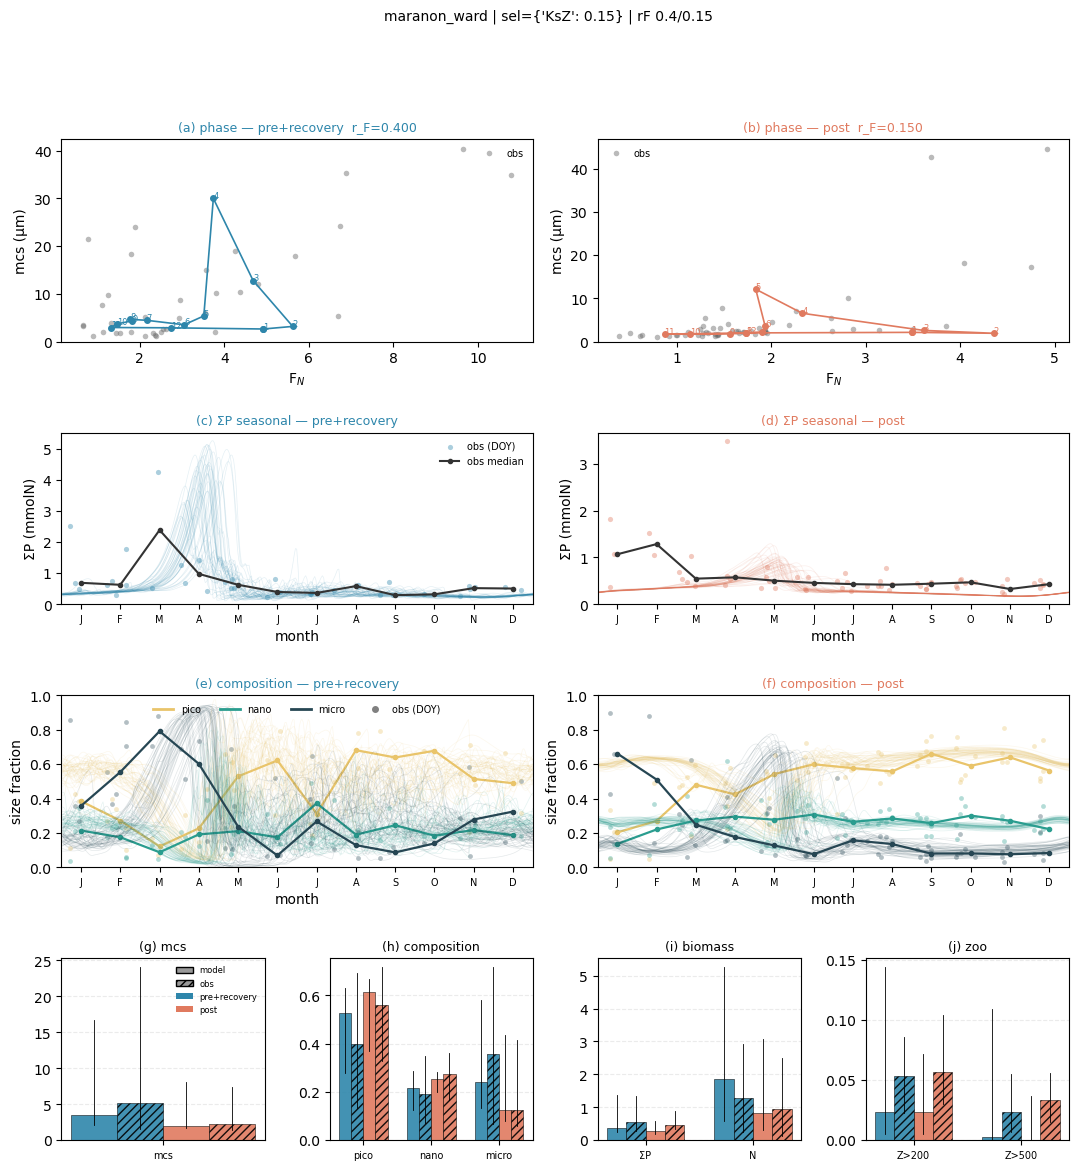

In [29]:
# === Fig 4 overview, callable on scan output =========================================
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D; from matplotlib.patches import Patch
import seasonal_scan_harness as ssh
from baseline_r0_seasonal_comps import _MID_MONTH_DOY

def _plot_fig4(runs, FISH, ERAS, suptitle, spinup=15):
    SPINUP=spinup; _MO=np.arange(1,13); MO=['J','F','M','A','M','J','J','A','S','O','N','D']
    ECOL={'pre+recovery':'#2E86AB','post':'#E07A5F'}; CLS=[('pico','#E9C46A'),('nano','#2A9D8F'),('micro','#264653')]
    obs_m=ssh.build_obs_monthly(ERAS,forcing_complete=True)
    def doy_to_mo(d): return np.interp(np.asarray(d,float),np.r_[0,_MID_MONTH_DOY,365],np.r_[0.5,_MO.astype(float),12.5])
    def ox(df,col='doy_hplc'):
        d=df[col] if col in df else pd.Series(np.nan,index=df.index)
        return np.where(np.isfinite(d),doy_to_mo(d),df['mo'])
    def _clim(r,k):
        keep=r['t']>=SPINUP*365.0; mo=np.clip(np.searchsorted(ssh._MEDGES,np.mod(r['t'][keep],365.0),'right')+1,1,12)
        v=np.asarray(r[k],float)[keep]; return np.array([np.nanmean(v[mo==m]) if np.any(mo==m) else np.nan for m in _MO])
    def _vals(r,k):
        keep=r['t']>=SPINUP*365.0; t=r['t'][keep]; mo=np.clip(np.searchsorted(ssh._MEDGES,np.mod(t,365.0),'right')+1,1,12)
        yr=(t/365.0).astype(int); v=np.asarray(r[k],float)[keep]
        return np.array([np.nanmean(v[(yr==y)&(mo==m)]) for y in np.unique(yr) for m in _MO if np.any((yr==y)&(mo==m))])
    def _daily(r,k):
        keep=r['t']>=SPINUP*365.0; t=r['t'][keep]; v=np.asarray(r[k],float)[keep]; doy=np.mod(t,365.0); yr=(t/365.0).astype(int); out=[]
        for y in np.unique(yr): m=yr==y; o=np.argsort(doy[m]); out.append((doy[m][o],v[m][o]))
        return out
    def _d2m(d): return np.interp(d,np.r_[0,_MID_MONTH_DOY,365],np.r_[0.5,_MO.astype(float),12.5])
    def _bar(ax,x,vals,c,h=None,w=0.18):
        v=np.asarray(vals,float); v=v[np.isfinite(v)]
        if v.size==0: return
        lo,hi=np.percentile(v,[10,90]); ax.bar(x,np.median(v),w,color=c,alpha=.9,hatch=h,edgecolor='k',lw=.4,zorder=2); ax.plot([x,x],[lo,hi],color='k',lw=.6,zorder=4)
    fig=plt.figure(figsize=(13,13)); gs=GridSpec(4,4,figure=fig,height_ratios=[1,.85,.85,.9],hspace=.5,wspace=.32)
    for col,era in zip([slice(0,2),slice(2,4)],ERAS):
        ax=fig.add_subplot(gs[0,col]); c=ECOL[era]; r=runs[era]; fn,mc=_clim(r,'FN'),_clim(r,'mcs'); o=np.r_[np.arange(12),0]
        ax.plot(fn[o],mc[o],'-o',color=c,lw=1.2,ms=4)
        for m in _MO: ax.annotate(str(m),(fn[m-1],mc[m-1]),fontsize=6,color=c)
        om=obs_m[era].dropna(subset=['FN','mcs']); ax.scatter(om['FN'],om['mcs'],s=16,color='0.4',alpha=.45,lw=0,label='obs')
        ax.set_xlabel('F$_N$'); ax.set_ylabel('mcs (µm)'); ax.set_ylim(bottom=0)
        ax.set_title(f"({'ab'[ERAS.index(era)]}) phase — {era}  r_F={FISH[era]:.3f}",fontsize=9,color=c); ax.legend(fontsize=7,frameon=False)
    for col,era in zip([slice(0,2),slice(2,4)],ERAS):
        ax=fig.add_subplot(gs[1,col]); r=runs[era]; c=ECOL[era]; om=obs_m[era].dropna(subset=['sumP'])
        for doy,v in _daily(r,'sumP'): ax.plot(_d2m(doy),v,'-',color=c,alpha=.12,lw=.5)
        ax.scatter(ox(om),om['sumP'],s=14,color=c,alpha=.4,lw=0,label='obs (DOY)')
        ax.plot(_MO,om.groupby('mo')['sumP'].median().reindex(_MO).values,'-o',color='0.2',lw=1.5,ms=3,label='obs median')
        allv=np.concatenate([v for _,v in _daily(r,'sumP')]+[om['sumP'].to_numpy()])
        ax.set_xlim(.5,12.5); ax.set_xticks(_MO); ax.set_xticklabels(MO,fontsize=7); ax.set_ylim(0,np.max(allv)*1.05)
        ax.set_xlabel('month'); ax.set_ylabel('ΣP (mmolN)'); ax.set_title(f"({'cd'[ERAS.index(era)]}) ΣP seasonal — {era}",fontsize=9,color=c)
        if col.start==0: ax.legend(fontsize=7,frameon=False)
    for col,era in zip([slice(0,2),slice(2,4)],ERAS):
        ax=fig.add_subplot(gs[2,col]); r=runs[era]; om=obs_m[era]
        for cls,cc in CLS:
            for doy,v in _daily(r,cls): ax.plot(_d2m(doy),v,'-',color=cc,alpha=.12,lw=.5)
            o=om.dropna(subset=[cls]); ax.scatter(ox(o),o[cls],s=12,color=cc,alpha=.35,lw=0)
            ax.plot(_MO,o.groupby('mo')[cls].median().reindex(_MO).values,'-o',color=cc,lw=1.6,ms=3)
        ax.set_xlim(.5,12.5); ax.set_xticks(_MO); ax.set_xticklabels(MO,fontsize=7); ax.set_ylim(0,1)
        ax.set_xlabel('month'); ax.set_ylabel('size fraction'); ax.set_title(f"({'ef'[ERAS.index(era)]}) composition — {era}",fontsize=9,color=ECOL[era])
        if col.start==0: ax.legend([Line2D([],[],color=cc,lw=2) for _,cc in CLS]+[Line2D([],[],color='.5',marker='o',ls='',ms=4)],[c for c,_ in CLS]+['obs (DOY)'],fontsize=7,frameon=False,ncol=4,loc='upper center')
    BP=[('(g) mcs',[('mcs','mcs')]),('(h) composition',[('pico','pico'),('nano','nano'),('micro','micro')]),('(i) biomass',[('ΣP','sumP'),('N','N')]),('(j) zoo',[('Z>200','Z200'),('Z>500','Z500')])]
    W=0.18; OFF={('pre+recovery','m'):-1.5*W,('pre+recovery','o'):-.5*W,('post','m'):.5*W,('post','o'):1.5*W}
    for j,(title,metrics) in enumerate(BP):
        ax=fig.add_subplot(gs[3,j])
        for i,(lab,key) in enumerate(metrics):
            for era in ERAS:
                c=ECOL[era]; _bar(ax,i+OFF[(era,'m')],_vals(runs[era],key),c,None,W)
                obs=obs_m[era][key].dropna().to_numpy() if key in obs_m[era].columns else np.array([])
                _bar(ax,i+OFF[(era,'o')],obs,c,'////',W)
        ax.set_xticks(range(len(metrics))); ax.set_xticklabels([m[0] for m in metrics],fontsize=7); ax.set_title(title,fontsize=9); ax.set_ylim(bottom=0); ax.grid(axis='y',ls='--',alpha=.25)
        if j==0: ax.legend([Patch(fc='.6',ec='k'),Patch(fc='.6',ec='k',hatch='////')]+[Patch(fc=ECOL[e]) for e in ERAS],['model','obs']+list(ERAS),fontsize=6,frameon=False)
    fig.suptitle(suptitle,fontsize=10); plt.show()

def fig4_overview(RP, RQ, rF_pre, rF_post, sel=None, construct='maranon_ward',
                  years=60, spinup=15, n_harmonics=3, routed=True, title=None):
    """Re-run + plot the Fig 4 overview for a (pre,post) pair from scan results RP (pre) / RQ (post).
    `sel` disambiguates the swept param, e.g. sel={'KsZ':0.15}. Construct params are taken from the
    PRE record (shared across eras); only r_F differs by era. Returns (runs, clims)."""
    ERAS=['pre+recovery','post']; FISH={'pre+recovery':rF_pre,'post':rF_post}
    spec=ssh.allometry(construct) if isinstance(construct,str) else construct
    def _find(R,f):
        for r in R.records:
            if abs(r['fish']-f)<1e-9 and all(abs(r.get(k,np.nan)-v)<1e-9 for k,v in (sel or {}).items()): return r
        raise ValueError(f"no record fish={f} sel={sel}")
    rec=_find(RP,rF_pre)                                   # shared construct -> reconstruct from pre
    ivo,mP,mZ={},None,None
    for k in RP.param_names:
        v=rec[k]
        if k=='mP': mP=v; continue
        if k=='m_Z': mZ=v; continue
        if k in ('mu_scale','graze_scale'): continue
        slot,key=ssh._PARAM_SLOT[k]; ivo.setdefault(slot,{})[key]=v
    runs,clims={},{}
    for era,f in FISH.items():
        print(f"\n##### {era}  r_F={f} #####"); ssh.describe_run(spec, RP.forcings[era], fish_rate=f,
            mP=mP, m_Z=mZ, iv_overrides=ivo, n_harmonics=n_harmonics, routed=routed)
        clim,r=ssh.run_one(spec, RP.forcings[era], fish_rate=f, mP=mP, m_Z=mZ, iv_overrides=ivo,
            years=years, spinup=spinup, n_harmonics=n_harmonics, routed=routed, return_traj=True)
        runs[era],clims[era]=r,clim
    OBS={'pre+recovery':RP.obs['pre+recovery'],'post':RQ.obs['post']}; K5=['mcs','pico','nano','micro','sumP']; W={k:1. for k in K5}
    f5=lambda c,g: float(np.nanmax([ssh.score({k:c.get(k+'_med',np.nan) for k in K5},OBS[g]['med'],W),
                                    ssh.score({k:c.get(k,np.nan) for k in K5},OBS[g]['mean'],W)]))
    inv=clims['post']['Z200_med']-clims['pre+recovery']['Z200_med']
    print(f"\nfit5 pre {f5(clims['pre+recovery'],'pre+recovery'):.4f} | post {f5(clims['post'],'post'):.4f} "
          f"| inv {inv:+.4f} (obs {OBS['post']['med']['Z200']-OBS['pre+recovery']['med']['Z200']:+.4f}) "
          f"| cv {clims['pre+recovery']['cv_sumP']:.2f}/{clims['post']['cv_sumP']:.2f} "
          f"| pze {clims['pre+recovery']['pze']:.2f}/{clims['post']['pze']:.2f}")
    _plot_fig4(runs, FISH, ERAS, title or f"{spec.get('name','?')} | sel={sel} | rF {rF_pre}/{rF_post}", spinup)
    return runs, clims

# --- examples (uses RP/RQ from the KsZ readout cell) ---
#runs,clims = fig4_overview(RP, RQ, 0.65, 0.10, sel={'KsZ':0.23})   # current baseline
#runs,clims = fig4_overview(RP, RQ, 0.50, 0.10, sel={'KsZ':0.15}) # lower & calmer pre candidate
runs,clims = fig4_overview(RP, RQ, 0.40, 0.15, sel={'KsZ':0.15})